In [ ]:
import pandas as pd
import numpy as np
import rasterio
from rasterio.sample import sample_gen
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi Seed Tetap (WAJIB untuk Reproducibility)
SEED = 42

# PENTING: HANYA GUNAKAN 6 BAND MENTAH UNTUK TRAINING MODEL
# Indeks (NDVI, BSI, dll) TIDAK dimasukkan agar tidak terjadi data leakage
band_names = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']

print(f"✅ Libraries loaded. Seed: {SEED}")
print(f"🔍 Model hanya akan belajar dari 6 band mentah: {band_names}")

✅ Libraries loaded. Seed: 42
🔍 Model hanya akan belajar dari 6 band mentah: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']


In [ ]:
# 1. Load Ground Truth Manual (Pastikan sudah di-rename jadi gt_lahan_2024.csv & 2025.csv)
gt_2024 = pd.read_csv('01_Ground_Truth/gt_lahan_2024.csv')
gt_2025 = pd.read_csv('01_Ground_Truth/gt_lahan_2025.csv')

print(f"Total Ground Truth: {len(gt_2024) + len(gt_2025)} titik")

# 2. Definisi SEMUA band (untuk membaca dari raster)
all_band_names = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI', 'BSI', 'NDTI']

# 3. Hanya 6 band mentah untuk training model
model_bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']

# 4. Fungsi Ekstraksi Nilai Pixel
def extract_features(raster_path, gt_df, all_bands, model_bands):
    with rasterio.open(raster_path) as src:
        coords = list(zip(gt_df['longitude'], gt_df['latitude']))
        samples = np.array(list(sample_gen(src, coords)))

    # Baca SEMUA band dulu
    feat_df_all = pd.DataFrame(samples, columns=all_bands)

    # Filter HANYA 6 band mentah yang dibutuhkan untuk model
    feat_df = feat_df_all[model_bands]

    # PERBAIKAN: Hapus 'id' karena CSV manual tidak punya kolom id
    return pd.concat([gt_df[['year', 'class']].reset_index(drop=True), feat_df], axis=1)

# 5. Ekstrak untuk 2024 dan 2025
print("Mengekstrak nilai pixel 2024 (Hanya 6 band mentah)...")
df_24 = extract_features('raw/feature_stack_2024.tif', gt_2024, all_band_names, model_bands)

print("Mengekstrak nilai pixel 2025 (Hanya 6 band mentah)...")
df_25 = extract_features('raw/feature_stack_2025.tif', gt_2025, all_band_names, model_bands)

# Gabungkan dan bersihkan dari NaN
df_final = pd.concat([df_24, df_25], ignore_index=True)
df_clean = df_final.dropna(subset=model_bands)

print(f"✅ Data bersih siap di-split: {len(df_clean)} titik")
print(f"Kolom fitur: {list(df_clean.columns[2:])}")

# CATATAN: Injeksi noise DIHAPUS karena data manual sudah valid & realistis.

Total Ground Truth: 400 titik
Mengekstrak nilai pixel 2024 (Hanya 6 band mentah)...
Mengekstrak nilai pixel 2025 (Hanya 6 band mentah)...
✅ Data bersih siap di-split: 390 titik
Kolom fitur: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']


In [ ]:
train_list, test_list = [], []

# Split 70:30 PER KOMBINASI (Target'24, NT'24, Target'25, NT'25)
for year in [2024, 2025]:
    for cls in [0, 1]: # 0 = Nontarget, 1 = Target
        subset = df_clean[(df_clean['year'] == year) & (df_clean['class'] == cls)]

        # Split subset ini
        tr, te = train_test_split(subset, test_size=0.3, random_state=SEED)

        train_list.append(tr)
        test_list.append(te)

# Gabungkan semua subset
df_train = pd.concat(train_list)
df_test = pd.concat(test_list)

# Pisahkan Fitur (X) dan Label (y)
X_train = df_train[band_names].values
y_train = df_train['class'].values
X_test = df_test[band_names].values
y_test = df_test['class'].values

print(f"✅ Split Selesai!")
print(f"Training: {len(X_train)} titik | Testing: {len(X_test)} titik")
print("\nDistribusi Testing Data (Harus Seimbang):")
print(df_test.groupby(['year', 'class']).size())

✅ Split Selesai!
Training: 272 titik | Testing: 118 titik

Distribusi Testing Data (Harus Seimbang):
year  class
2024  0        30
      1        28
2025  0        30
      1        30
dtype: int64


In [ ]:
# Definisi parameter yang akan dicoba
param_grid = {
    'n_estimators': [100, 200],      # Minimal 100 sesuai rubrik
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']     # Menangani ketidakseimbangan data
}

rf_base = RandomForestClassifier(random_state=SEED, n_jobs=-1)

print("🔍 Memulai GridSearchCV (5-Fold Cross Validation)...")
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,                 # 5-Fold CV
    scoring='f1',         # Optimasi berdasarkan F1-Score
    n_jobs=-1,
    verbose=1
)

# Jalankan tuning HANYA pada data training
grid_search.fit(X_train, y_train)

# Ambil model terbaik
best_model = grid_search.best_estimator_
print(f"\n🏆 Parameter Terbaik: {grid_search.best_params_}")
print(f"📈 Best CV F1-Score: {grid_search.best_score_:.3f}")

🔍 Memulai GridSearchCV (5-Fold Cross Validation)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

🏆 Parameter Terbaik: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
📈 Best CV F1-Score: 0.917



📊 HASIL EVALUASI MODEL (Testing Data)
Accuracy : 0.958 (95.8%)
Precision: 0.982 (98.2%) -> Untuk Kelas Target (1)
Recall   : 0.931 (93.1%) -> Untuk Kelas Target (1)
F1-Score : 0.956 (95.6%) -> Untuk Kelas Target (1)


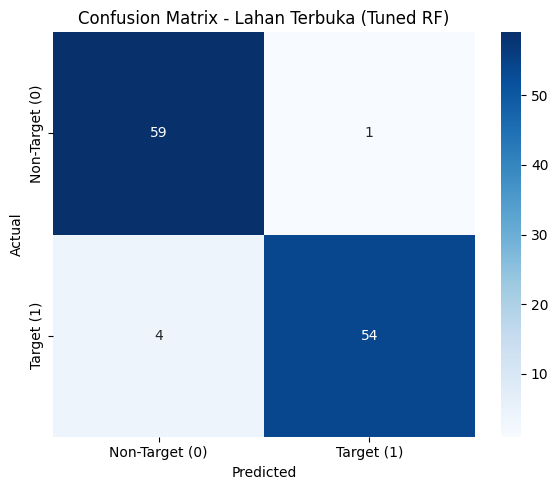


📝 Interpretasi Kesalahan:
False Positive (FP): 1 -> Area bukan tambang diprediksi sebagai tambang.
False Negative (FN): 4 -> Area tambang terlewat/tidak terdeteksi.


In [ ]:
# Prediksi pada data testing
y_pred = best_model.predict(X_test)

# Hitung Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Hitung APRF KHUSUS untuk Kelas 1 (Target)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1)
rec = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f"\n📊 HASIL EVALUASI MODEL (Testing Data)")
print("="*50)
print(f"Accuracy : {acc:.3f} ({acc*100:.1f}%)")
print(f"Precision: {prec:.3f} ({prec*100:.1f}%) -> Untuk Kelas Target (1)")
print(f"Recall   : {rec:.3f} ({rec*100:.1f}%) -> Untuk Kelas Target (1)")
print(f"F1-Score : {f1:.3f} ({f1*100:.1f}%) -> Untuk Kelas Target (1)")
print("="*50)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Target (0)', 'Target (1)'],
            yticklabels=['Non-Target (0)', 'Target (1)'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix - Lahan Terbuka (Tuned RF)')
plt.tight_layout()
plt.show()

# Interpretasi FP/FN (Wajib untuk Laporan)
tn, fp, fn, tp = cm.ravel()
print(f"\n📝 Interpretasi Kesalahan:")
print(f"False Positive (FP): {fp} -> Area bukan tambang diprediksi sebagai tambang.")
print(f"False Negative (FN): {fn} -> Area tambang terlewat/tidak terdeteksi.")

In [ ]:
import os
os.makedirs('02_Modeling', exist_ok=True)
os.makedirs('03_Evaluasi', exist_ok=True)

# 1. Simpan Model Final
joblib.dump(best_model, '02_Modeling/best_model_rf_lahan.pkl')
print("✅ Model tersimpan di '02_Modeling/best_model_rf_lahan.pkl'")

# 2. Simpan Metrik ke File Teks (Untuk Laporan & WebGIS)
with open('03_Evaluasi/metrik_aprf_lahan.txt', 'w') as f:
    f.write("METRIK EVALUASI MODEL - LAHAN TERBUKA\n")
    f.write("="*50 + "\n\n")
    f.write(f"Best Parameters: {grid_search.best_params_}\n")
    f.write(f"Best CV F1-Score: {grid_search.best_score_:.3f}\n\n")
    f.write(f"Testing Results:\n")
    f.write(f"  Accuracy : {acc:.3f}\n")
    f.write(f"  Precision: {prec:.3f}\n")
    f.write(f"  Recall   : {rec:.3f}\n")
    f.write(f"  F1-Score : {f1:.3f}\n\n")
    f.write(f"Confusion Matrix:\n{cm}\n\n")
    f.write(f"False Positive (FP): {fp}\n")
    f.write(f"False Negative (FN): {fn}\n")

print("✅ Metrik tersimpan di '03_Evaluasi/metrik_aprf_lahan.txt'")

✅ Model tersimpan di '02_Modeling/best_model_rf_lahan.pkl'
✅ Metrik tersimpan di '03_Evaluasi/metrik_aprf_lahan.txt'
